# Run the Generalized IOP (GIOP) inversion model in the Level-2 Generator`l2gen` OCSSW program on OCI data

**Authors:** Anna Windle (NASA, SSAI), Jeremy Werdell (NASA) <br>
Last updated: August 3, 2025


<div class="alert alert-success" role="alert">

The following notebooks are **prerequisites** for this tutorial.

- Learn with OCI: [Data Access][oci-data-access]
- Learn with OCI: [Installing and Running OCSSW Command-line Tools][ocssw_install]
- Learn with OCI: [Run Level-2 Generator (l2gen) OCSSW program on OCI data][ocssw_l2gen]

</div>

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA ocean color data.

</div>

<div class="alert alert-info" role="alert">

This notebook was desgined to use cloud-enabled OCSSW programs, which are available in OCSSW tag V2025.2 or higher. Cloud-enabled OCSSW programs can only be run on an AWS EC2 instance, such as CryoCloud.

</div>

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[ocssw_install]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_ocssw_install/
[ocssw_l2gen]: tbd

## Summary

The [OceanColor Science SoftWare][ocssw] (OCSSW) repository is the operational data processing software package of NASA's Ocean Biology Distributed Active Archive Center (OB.DAAC). OCSSW is publically available through the OB.DAAC's [Sea, earth, and atmosphere Data Analysis System][seadas] (SeaDAS), which provides a complete suite of tools to process, display and analyze ocean color data. SeaDAS is a desktop application that provides GUI access to OCSSW, but command line interfaces (CLI) also exist, which we can use to write processing scripts and notebooks without the desktop application.

In a previous tutorial, we demonstrated how to run the Level-2 Generator (`l2gen`) program to generate aquatic Level-2 (L2) data products from calibrated top-of-atmosphere (TOA) radiances. In practice, `l2gen` not only allows generation of aquatic geophysical products, but also the capability to (re)parameterize the algorithms used to generate them. For example, inherent optical properties (IOPs) are routinely produced and distributed as part of NASA standard L2 and Level-3 (L3) IOP suites, inclusive of spectral absorption and backscattering coefficients and their subcomponents. These standard products are generated using the default configuration of the Generalized IOP (GIOP) framework [(Werdell et al., 2013)][werdell]. Using `l2gen`, you can select options to generate additional IOPs or reconfigure the parameterization of GIOP.

This tutorial will demonstrate how to process PACE OCI L1B data through `l2gen` to retrieve the standard L2 IOP data suite. This tutorial wil also demonstrate how to modify the operation of `l2gen` confifurations based on your research needs. 

[seadas]: https://seadas.gsfc.nasa.gov/
[ocssw]: https://oceandata.sci.gsfc.nasa.gov/ocssw
[werdell]: https://oceancolor.gsfc.nasa.gov/staff/jeremy/werdell_et_al_2013_ao.pdf

## Learning Objectives

At the end of this notebook you will know:

- How to navigate and open files related to the GIOP within OCSSW directory
- How to process L1B data to retreive L2 IOPs with `l2gen` 
- Modifications you can make to `l2gen` to obtain different IOP products

## Contents

1. [Setup](#1.-Setup)
2. [Search and access L1B Data ](#2.-Search-and-Access-L1B-Data)
3. [Run `l2gen` with default GIOP configurations](#3.-Run-l2gen-with-default-GIOP-configurations)
4. [Plot L2 IOP data products](#4.-Plot-L2-IOP-data-products)
5. [Run GIOP with modifications to the configurations](#5.-Run-GIOP-with-modifications-to-the-configurations)

# 1. Setup

Begin by importing all of the packages used in this notebook. If your kernel uses an environment defined following the guidance on the [tutorials] page, then the imports will be successful.

[tutorials]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/

In [1]:
import csv
import os
from pathlib import Path

import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

Next, we'll set up the OCSSW programs. 

<div class="alert alert-warning">

OCSSW programs are system commands, typically called in a Bash shell. We will employ [system shell access][ipython] available in the IPython kernel to launch system commands as a subprocess using the `!` prefix. In the specific case of OCSSW programs, a suite of required environment variables must be set by first executing `source $OCSSWROOT/OCSSW_bash.env` in the same subprocess.

</div>

Every time we use `!` to invoke an OCSSW program, we must also evaluate the `OCSSW_bash.env` environment file shipped with OCSSW. Each `!` initiated subprocess is distinct, and the environment configuration is discarded after the command is finished. Let's get prepared by reading the path to the OCSSW installation from the `OCSSWROOT` environment variable (assuming it's `/tmp/ocssw` as a fallback).

[ipython]: https://ipython.readthedocs.io/en/stable/interactive/reference.html#system-shell-access

In [2]:
ocsswroot = os.environ.setdefault("OCSSWROOT", "/tmp/ocssw")
env = Path(ocsswroot, "OCSSW_bash.env")
env.exists()

True

Our first OCSSW program is `install_ocssw`, which we use to print which version (tag) of OCSSW is installed. As just explained, we have to evaluate (or `source`) the environment configuration file first. To pass its location, we use `{}` variable expansion that is available with the `!` prefix.

In [3]:
!source {env}; install_ocssw --installed_tag



installedTag = V2025.2


The `installedTag` is our OCSSW version. Tags beginning with "V" are operational tags, while "T" tags are equivalent to a "beta" release and meant for testing by advanced users.

## Setting up AWS S3 credentials

Accessing data from NASA's Earthdata Cloud, regardless of the tool, requires authentication.
The `earthaccess` package works behind-the-scenes using the Earthdata Login credentials you provide to generate temporary AWS credentials for direct access to the Earthdata Cloud.

In [4]:
earthaccess.login(persist=True)
credentials = earthaccess.get_s3_credentials(provider="OB_CLOUD")

The OCSSW software accepts AWS credentials in all the usual methods, including via environment variables that we set in the next cell.

In [5]:
os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": credentials["accessKeyId"],
        "AWS_SECRET_ACCESS_KEY": credentials["secretAccessKey"],
        "AWS_SESSION_TOKEN": credentials["sessionToken"],
    }
)

<div class="alert alert-warning">

Earthdata Cloud sets a one-hour lifespan on your temporary AWS credentials. If you get an `access denied` error, re-run the cell above to generate new AWS credentials.

<div>

## Navigating GIOP files in OCSSW

In the 'Run Level-2 Generator (l2gen) OCSSW program on OCI data' tutorial, we learned how to navigate files within the OCSSW directory.

### The IOP product suite

Let's take a look at the msl12_defaults_IOP.par file, which is the "parameter" file that defines the default IOP suite for OCI:

In [6]:
!cat $OCSSWROOT/share/oci/msl12_defaults_IOP.par

#
# IOP l2gen suite for OCI
#
proc_uncertainty=1
l2prod=a bb aph Kd adg_442 adg_s bbp_442 bbp_s rrsdiff aph_unc_442 adg_unc_442 bbp_unc_442
wavelength_3d=400,413,425,442,460,475,490,510,532,555,583,618,640,655,665,678,701

## IOP model for use in downstream products (e.g. Kd_###_lee)
##  7 = GIOP
iop_opt=7



Let's discuss some of these parameters: 

* proc_uncertainty=1 : Rrs uncertainty propagation mode, where 1 = uncertainty propagation generating error variance (and 0 = no uncertainty propagation and 2 = uncertainty propagation generating full covariance matrix)
<br><br>
* l2prod=a bb aph Kd adg_442 adg_s bbp_442 bbp_s rrsdiff aph_unc_442 adg_unc_442 bbp_unc_442 : a list of the geophysical products to be included in the L2 output file; not defining a wavelength outputs all defined wavelengths
<br><br>
* wavelength_3d=400,413,425,442,460,475,490,510,532,555,583,618,640,655,665,678,701 : the wavelengths to be output
<br><br>
* iop_opt=7 : the IOP model used for use in downstream product (e.g., spectral diffuse attenuation coefficients, where 7 = GIOP)

So, running the 'IOP l2gen suite' produces these L2 data products at 17 wavelengths unless otherwise defined.

<div class="alert alert-info">


GIOP attempts to simultaneously estimate the magnitudes of spectral backscattering by particles ($b_{bp}$(λ); m⁻¹), absorption by phytoplankton ($a_{ph}$(λ); m⁻¹), and the combined absorption by non-algal particles and colored dissolved organic material ($a_{dg}$(λ); m⁻¹). It assigns constant spectral values for seawater absorption and backscattering ($a_{w}$(λ) and $b_{bw}$(λ), respectively; m⁻¹), assumes spectral shape functions of the remaining constituent absorption and scattering components (those values denoted by an *), and retrieves the magnitudes of each remaining constituent (the Mₓ values in red) required to match the spectral distribution of $R_{rs}$(λ). The default configuration uses the following forward model:

$$
r_{rs}(\lambda) = G(\lambda) \cdot \frac{b_{bw}(\lambda) + {\color{red}M_{bp}}\, b^*_{bp}(\lambda)}{a_w(\lambda) + {\color{red}M_{ph}}\, a^*_{ph}(\lambda) + {\color{red}M_{dg}}\, a^*_{dg}(\lambda)}
$$

$r_{rs}$(λ) is subsurface remote sensing reflectance and G(λ) is a catch-all term that accounts for bidirectional reflectance distributions and other sea and sky conditions.

</div>

### GIOP's default parameterization

To find a couple other useful GIOP options, you can take a look at 'common/msl12_defaults.par' and 'oci/msl12_defaults.par'. <br>

As seen in these two files, the default GIOP parameterization is defined by:

* giop_fit_opt=1 (GIOP model optimization method. 1 = Levenberg-Marquardt (L-M) fit)
* giop_rrs_opt=0 (GIOP model Rrs to bb/(a+bb) method. 0 = Gordon quadratic; defines G(λ))
* giop_aph_opt=2 (GIOP model aph function type. 2 = Bricaud 1998 aph spectrum; defines aph*(λ))
* giop_adg_opt=1 (GIOP model adg function type. 1 = user-defined exponential adg function; defines adg*(λ))
* giop_adg_s=0.018 (spectral parameter for adg fixed at 0.018; defines adg*(λ) with above)
* giop_bbp_opt=3 (GIOP model bbp function type. 3 = power-law with exponent derived via Lee et al. (2002); defines bbp*(λ))
* raman_opt=2 (Raman scattering Rrs correction options. 2 = Westberry et al. (2013) analytical correction)
* giop_wave=[413,442,490,510,555,670] (wavelengths used in the L-M optimization)

Running `l2gen` on OCI data to produce the IOP data suite products will include these default options. The user must make modifications to produce different outputs. 

*Remember, you can find more information about these parameters, <b>and the other options available for each</b>, using 'l2gen --help'.*

## Writing OCSSW parameter files

User-generated parameter files provide a convenient way to control `l2gen` processing. 

Without a par file, providing `l2gen` the names of the input L1B and output L2 files from the Terminal looks like this:

```bash
l2gen ifile=data/PACE_OCI.20250507T170659.L1B.V3.nc ofile=data/PACE_OCI.20250507T170659.L2.V3.nc
```

Alternatively, a user-defined par file, say "l2gen.par", can be created with the following two lines of content:

    ifile=data/PACE_OCI.20250507T170659.L1B.V3.nc
    ofile=data/PACE_OCI.20250507T170659.L2.V3.nc

Now `l2gen` can now be called using the single argument `par` while generating the same result:

```bash
l2gen par=l2gen.par
```

You can imagine that the par file option becomes far more convenient when many changes from default are desired.

So let's define a function to help write OCSSW parameter files, which is needed several times in this tutorial. To write the results in the format understood by OCSSW, this function uses the `csv.writer` from the Python Standard Library. Instead of writing comma-separated values, however, we specify a non-default delimiter to get equals-separated values. Not something you usually see in a data file, but it's better than writing our own utility from scratch!

In [7]:
def write_par(path, par):
    """Prepare a parameter file to be read by one of the OCSSW tools.

    Using a parameter file (a.k.a. "par file") is equivalent to specifying
    parameters on the command line.

    Parameters
    ----------
    path
        where to write the parameter file
    par
        the parameter names and values included in the file
    """
    with open(path, "w") as file:
        writer = csv.writer(file, delimiter="=")
        writer.writerows(par.items())

[back to top](#Contents)

# 2. Search and access L1B data 

Let's use the earthaccess Python package to access a L1B file.

In [8]:
tspan = ("2025-05-07", "2025-05-07")
bbox = {"west": -76, "south": 35, "east": -74.5, "north": 39}

results = earthaccess.search_data(
    short_name="PACE_OCI_L1B_SCI",
    temporal=tspan,
    bounding_box=tuple(bbox.values()),
)
results[0]

Collection: {'Version': '3', 'ShortName': 'PACE_OCI_L1B_SCI'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 43.18293, 'Longitude': -54.08183}, {'Latitude': 37.42979, 'Longitude': -85.12212}, {'Latitude': 20.1135, 'Longitude': -77.9056}, {'Latitude': 25.34842, 'Longitude': -52.29907}, {'Latitude': 43.18293, 'Longitude': -54.08183}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-05-07T17:11:58Z', 'BeginningDateTime': '2025-05-07T17:06:59Z'}}
Size(MB): 1788.2080850601196
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250507T170659.L1B.V3.nc']

In [9]:
l1b_paths = earthaccess.open(results)
l1b_paths

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[<File-like object S3FileSystem, ob-cumulus-prod-public/PACE_OCI.20250507T170659.L1B.V3.nc>]

And let's do a quick plot of a `rhot_red` wavelength to see what the data looks like:

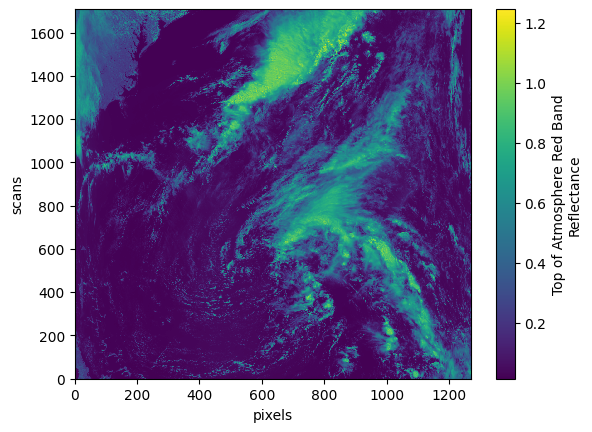

In [10]:
dataset = xr.open_datatree(l1b_paths[0])
dataset = xr.merge(dataset.to_dict().values())
dataset = dataset.set_coords(("longitude", "latitude"))
plot = dataset["rhot_red"].sel({"red_bands": 100}).plot()

[back to top](#Contents)

# 3. Run `l2gen` with default GIOP configurations

Let's now run `l2gen` using the default GIOP configuration.

In [11]:
l1b_path = l1b_paths[0].full_name
l1b_name = Path(l1b_path).name

Let's write a .par file that has an ifile, ofile, IOP data suite, and latitude and longitude boundaries (subsetting the L1B file to a smaller region makes processing time faster for this demo). We'll also include l2prod and select all of the standard IOP data products plus the eigenvalues, or the magnitudes of the IOPs retrieved in the optimization. To do this, we have to add "fit_par_X_giop" which wil produce the eigenvalues in the order of M_aph, M_adg, M_bbp.

Let's also first make a folder called 'data' to store the outputs:

In [12]:
data = Path("data")
data.mkdir(exist_ok=True)

In [13]:
par = {
    "ifile": l1b_path,
    "ofile": data / l1b_name.replace("L1B", "L2_IOP"),
    "suite": "IOP",
    **bbox,
    "l2prod": " ".join([
        "fit_par_1_giop",
        "fit_par_2_giop",
        "fit_par_3_giop",
        "a",
        "bb",
        "aph",
        "Kd",
        "adg_442",
        "adg_s",
        "bbp_442",
        "bbp_s",
        "rrsdiff",
        "aph_unc_442",
        "adg_unc_442",
        "bbp_unc_442",
    ]),
}
write_par("l2gen_iop.par", par)

A file named "l2gen_iop.par" should now appear in your working directory.

Now, let's run `l2gen` using this new .par file. This can take several minutes.

In [14]:
!source {env}; l2gen par=l2gen_iop.par

Loading default parameters from /opt/ocssw/share/common/msl12_defaults.par


Input file s3://ob-cumulus-prod-public/PACE_OCI.20250507T170659.L1B.V3.nc is PACE L1B file.

Loading characteristics for OCI
Opening sensor information file /opt/ocssw/share/oci/msl12_sensor_info.dat


  Bnd   Lam       Fo    Tau_r     k_oz    k_no2    t_co2   awhite       aw      bbw
    0  314.550  112.329 4.880e-01 4.222e-01 3.282e-19 1.000e+00 0.000e+00 2.305e-01 6.356e-03
    1  316.239   92.673 6.491e-01 5.817e-01 2.960e-19 1.000e+00 0.000e+00 1.633e-01 7.727e-03
    2  318.262   85.208 7.410e-01 5.479e-01 2.844e-19 1.000e+00 0.000e+00 1.278e-01 8.187e-03
    3  320.303   82.100 7.807e-01 4.616e-01 2.833e-19 1.000e+00 0.000e+00 1.105e-01 8.271e-03
    4  322.433   80.692 7.906e-01 3.551e-01 2.898e-19 1.000e+00 0.000e+00 9.950e-02 8.190e-03
    5  324.649   86.329 7.916e-01 2.573e-01 3.019e-19 1.000e+00 0.000e+00 9.079e-02 8.041e-03
    6  326.828   95.925 7.891e-01 1.911e-01 3.132e-19 1.000e+00 0.000e+00 8.475e-02 7.871e-03
    7  328.988  101.478 7.699e-01 1.387e-01 3.251e-19 1.000e+00 0.000e+00 8.211e-02 7.627e-03
    8  331.305  101.788 7.403e-01 9.848e-02 3.418e-19 1.000e+00 0.000e+00 8.089e-02 7.342e-03
    9  333.958   98.128 7.205e-01 6.838e-02 3.572e-19 1.000e+00 0.000e

Loading gain and offset from calfile: /opt/ocssw/share/oci/cal/oci_gains_v3.1_20250722.nc


OCI L1B Npix  :1272 Nlines:1709


...

Processing scan #  1519 (251 of 382) after    222 seconds


Processing scan #  1569 (301 of 382) after    248 seconds


Processing scan #  1619 (351 of 382) after    266 seconds



Percentage of pixels flagged:
Flag # 1:          ATMFAIL          0   0.0000
Flag # 2:             LAND      12123  23.3350
Flag # 3:         PRODWARN      36385  70.0358
Flag # 4:          HIGLINT          0   0.0000
Flag # 5:             HILT         33   0.0635
Flag # 6:         HISATZEN          0   0.0000
Flag # 7:           COASTZ      14504  27.9181
Flag # 8:            SPARE          0   0.0000
Flag # 9:       STRAYLIGHT       9107  17.5296
Flag #10:           CLDICE       7489  14.4152
Flag #11:        COCCOLITH       3207   6.1730
Flag #12:          TURBIDW       5254  10.1132
Flag #13:         HISOLZEN          0   0.0000
Flag #14:            SPARE          0   0.0000
Flag #15:            LOWLW         35   0.0674
Flag #16:          CHLFAIL        113   0.2175
Flag #17:          NAVWARN          0   0.0000
Flag #18:           ABSAER          0   0.0000
Flag #19:            SPARE          0   0.0000
Flag #20:       MAXAERITER        350   0.6737
Flag #21:         MODGLINT   


Processing Completed


You'll know `l2gen` processing is finished when you see "Processing Completed" at the end of the cell output. 

Let's open up this new L2 data using XArray's open_datatree function:

In [15]:
dat = xr.open_datatree(par["ofile"])
dat = xr.merge(dat.to_dict().values())
dat = dat.set_coords(("longitude", "latitude"))
dat

<xarray.Dataset> Size: 17MB
Dimensions:         (number_of_bands: 286, number_of_reflective_bands: 286,
                     wavelength_3d: 17, number_of_lines: 382,
                     pixels_per_line: 136)
Coordinates:
  * wavelength_3d   (wavelength_3d) float64 136B 400.0 413.0 ... 678.0 701.0
    longitude       (number_of_lines, pixels_per_line) float32 208kB ...
    latitude        (number_of_lines, pixels_per_line) float32 208kB ...
Dimensions without coordinates: number_of_bands, number_of_reflective_bands,
                                number_of_lines, pixels_per_line
Data variables: (12/39)
    wavelength      (number_of_bands) float64 2kB ...
    vcal_gain       (number_of_reflective_bands) float32 1kB ...
    vcal_offset     (number_of_reflective_bands) float32 1kB ...
    F0              (number_of_reflective_bands) float32 1kB ...
    aw              (number_of_reflective_bands) float32 1kB ...
    bbw             (number_of_reflective_bands) float32 1kB ...
    ...              ...
    rrsdiff         (number_of_lines, pixels_per_line) float32 208kB ...
    aph_unc_442     (number_of_lines, pixels_per_line) float32 208kB ...
    adg_unc_442     (number_of_lines, pixels_per_line) float32 208kB ...
    bbp_unc_442     (number_of_lines, pixels_per_line) float32 208kB ...
    l2_flags        (number_of_lines, pixels_per_line) int32 208kB ...
    tilt            (number_of_lines) float32 2kB ...
Attributes: (12/47)
    title:                          OCI Level-2 Data IOP
    product_name:                   PACE_OCI.20250507T170659.L2_IOP.V3.nc
    processing_version:             Unspecified
    history:                        l2gen par=l2gen_iop.par
    instrument:                     OCI
    platform:                       PACE
    ...                             ...
    geospatial_lon_min:             -77.462875
    startDirection:                 Ascending
    endDirection:                   Ascending
    day_night_flag:                 Day
    earth_sun_distance_correction:  0.9819285869598389
    geospatial_bounds:              POLYGON ((35.29966 -73.16452, 34.70900 -7...

# 4. Plot L2 IOP data products

Let's plot each of the IOP variables:

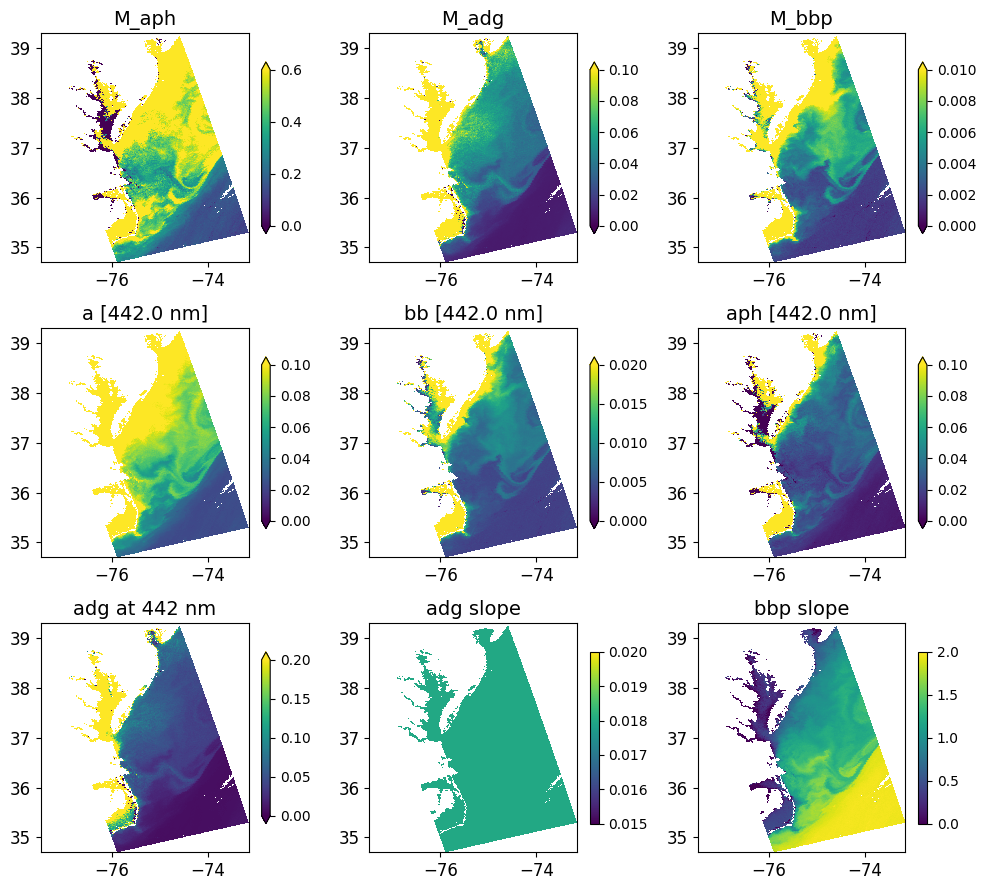

In [16]:
target_wavelength = 443
wl_idx = dat["wavelength_3d"].sel({"wavelength_3d": target_wavelength}, method="nearest").item()

vars_to_plot = {
    "fit_par_1_giop": "M_aph",
    "fit_par_2_giop": "M_adg",
    "fit_par_3_giop": "M_bbp",
    "a": f"a [{wl_idx:.1f} nm]",
    "bb": f"bb [{wl_idx:.1f} nm]",
    "aph": f"aph [{wl_idx:.1f} nm]",
    "adg_442": "adg at 442 nm",
    "adg_s": "adg slope",
    "bbp_s": "bbp slope",
}

limits = {
    "fit_par_1_giop": (0, 0.6),  # aph
    "fit_par_2_giop": (0, 0.1),  # adg
    "fit_par_3_giop": (0, 0.01),  # bbp
    "a": (0, 0.1),
    "bb": (0, 0.02),
    "aph": (0, 0.1),
    "adg_442": (0, 0.2),
    "adg_s": (0.015, 0.02),
    "bbp_s": (0, 2),
}

n = len(vars_to_plot)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 3 * nrows))
axes = axes.flatten()

for i, (var, title) in enumerate(vars_to_plot.items()):
    ax = axes[i]
    da = dat[var].sel({"wavelength_3d": wl_idx}) if var in ["a", "bb", "aph"] else dat[var]

    vmin, vmax = limits.get(var, (None, None))

    da.plot(
        ax=ax,
        x="longitude",
        y="latitude",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={"shrink": 0.75, "label": "", "orientation": "vertical"},
        add_labels=False,
    )
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=12)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

We can also plot the shapes of absorption (a), backscattering (bb), and aph (phytoplankton absorption). Let's choose two pixels from the scene shown in this map:

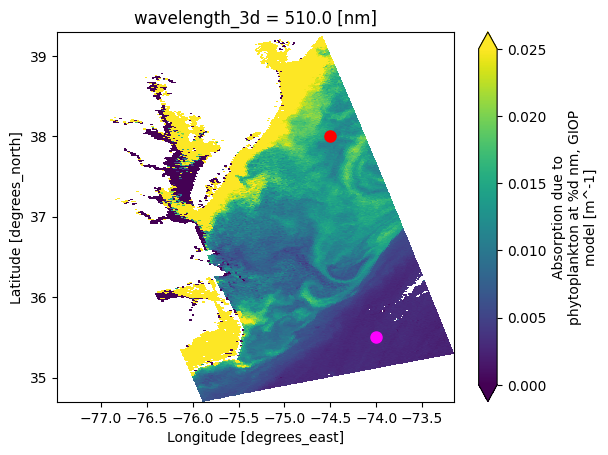

In [17]:
lat1, lon1 = 38, -74.5
lat2, lon2 = 35.5, -74
plot = (
    dat["aph"]
    .sel({"wavelength_3d": 510})
    .plot(x="longitude", y="latitude", vmin=0, vmax=0.025)
)
plt.plot(lon1, lat1, marker="o", color="red", markersize=8)
plt.plot(lon2, lat2, marker="o", color="magenta", markersize=8)
plt.show()

Use `argmin` to find the index in the `number_of_lines` and `pixels_per_line` dimension of the nearest pixel center to each station, and concatentate the result into a dataset with a `station` dimension.

In [18]:
distance1 = np.sqrt((dat.latitude - lat1) ** 2 + (dat.longitude - lon1) ** 2)
index1 = distance1.argmin(...)

distance2 = np.sqrt((dat.latitude - lat2) ** 2 + (dat.longitude - lon2) ** 2)
index2 = distance2.argmin(...)

station_dat = xr.concat((dat[index1], dat[index2]), "station")
station_dat

<xarray.Dataset> Size: 24kB
Dimensions:         (station: 2, number_of_bands: 286,
                     number_of_reflective_bands: 286, wavelength_3d: 17)
Coordinates:
  * wavelength_3d   (wavelength_3d) float64 136B 400.0 413.0 ... 678.0 701.0
    longitude       (station) float32 8B -74.49 -73.99
    latitude        (station) float32 8B 38.0 35.51
Dimensions without coordinates: station, number_of_bands,
                                number_of_reflective_bands
Data variables: (12/39)
    wavelength      (station, number_of_bands) float64 5kB 315.0 ... 2.258e+03
    vcal_gain       (station, number_of_reflective_bands) float32 2kB 1.0 ......
    vcal_offset     (station, number_of_reflective_bands) float32 2kB 0.0 ......
    F0              (station, number_of_reflective_bands) float32 2kB 1.123e+...
    aw              (station, number_of_reflective_bands) float32 2kB 0.0947 ...
    bbw             (station, number_of_reflective_bands) float32 2kB 0.00963...
    ...              ...
    rrsdiff         (station) float32 8B 0.01471 0.006201
    aph_unc_442     (station) float32 8B 0.0031 0.0005
    adg_unc_442     (station) float32 8B 0.0023 0.0002
    bbp_unc_442     (station) float32 8B 0.000235 5.001e-05
    l2_flags        (station) int32 8B 4 4
    tilt            (station) float32 8B 19.86 19.86
Attributes: (12/47)
    title:                          OCI Level-2 Data IOP
    product_name:                   PACE_OCI.20250507T170659.L2_IOP.V3.nc
    processing_version:             Unspecified
    history:                        l2gen par=l2gen_iop.par
    instrument:                     OCI
    platform:                       PACE
    ...                             ...
    geospatial_lon_min:             -77.462875
    startDirection:                 Ascending
    endDirection:                   Ascending
    day_night_flag:                 Day
    earth_sun_distance_correction:  0.9819285869598389
    geospatial_bounds:              POLYGON ((35.29966 -73.16452, 34.70900 -7...

The spectral plots for the two stations.

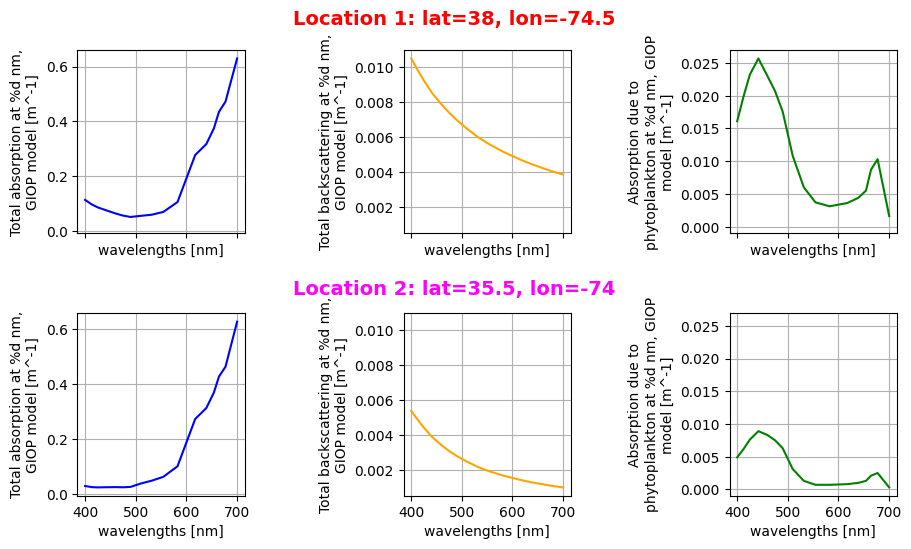

In [19]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey="col")
fig.text(
    0.5,
    0.95,
    f"Location 1: lat={lat1}, lon={lon1}",
    ha="center",
    fontsize=14,
    weight="bold",
    color="red",
)
fig.text(
    0.5,
    0.5,
    f"Location 2: lat={lat2}, lon={lon2}",
    ha="center",
    fontsize=14,
    weight="bold",
    color="magenta",
)

station_dat["a"][0].plot(ax=axs[0, 0], color="blue")
station_dat["a"][1].plot(ax=axs[1, 0], color="blue")
station_dat["bb"][0].plot(ax=axs[0, 1], color="orange")
station_dat["bb"][1].plot(ax=axs[1, 1], color="orange")
station_dat["aph"][0].plot(ax=axs[0, 2], color="green")
station_dat["aph"][1].plot(ax=axs[1, 2], color="green")

for ax in axs.flat:
    ax.set_title(None)
    ax.grid(True)

fig.tight_layout(pad=4.0)
plt.show()

# 5. Run GIOP with modifications to the configurations

There are many ways you can configure GIOP to run to best suit your research needs. Let's say you want to run the GIOP with a dynamic $S_{dg}$ calculation instead of the default fixed value at 0.018 $nm^{-1}$. We can choose to use the QAA dynamic calculation instead by setting giop_adg_opt to 2 (exponential with exponent derived via [Lee et al. (2002)](Lee), and removing giop_adg_s from the l2prod in the par file:

[Lee]: https://doi.org/10.1364/AO.41.005755

In [20]:
par = {
    "ifile": l1b_path,
    "ofile": data / l1b_name.replace("L1B", "L2_IOP_mod"), 
    "suite": "IOP",
    **bbox,
    "giop_adg_opt": 2,
    "l2prod": " ".join([
        "fit_par_1_giop",
        "fit_par_2_giop",
        "fit_par_3_giop",
        "a",
        "bb",
        "aph",
        "Kd",
        "adg_442",
        "bbp_442",
        "bbp_s",
        "rrsdiff",
        "aph_unc_442",
        "adg_unc_442",
        "bbp_unc_442",
    ]),
}
write_par("l2gen_iop_mod.par", par)

In [21]:
!source {env}; l2gen par=l2gen_iop_mod.par 

Loading default parameters from /opt/ocssw/share/common/msl12_defaults.par


Input file s3://ob-cumulus-prod-public/PACE_OCI.20250507T170659.L1B.V3.nc is PACE L1B file.

Loading characteristics for OCI
Opening sensor information file /opt/ocssw/share/oci/msl12_sensor_info.dat


  Bnd   Lam       Fo    Tau_r     k_oz    k_no2    t_co2   awhite       aw      bbw
    0  314.550  112.329 4.880e-01 4.222e-01 3.282e-19 1.000e+00 0.000e+00 2.305e-01 6.356e-03
    1  316.239   92.673 6.491e-01 5.817e-01 2.960e-19 1.000e+00 0.000e+00 1.633e-01 7.727e-03
    2  318.262   85.208 7.410e-01 5.479e-01 2.844e-19 1.000e+00 0.000e+00 1.278e-01 8.187e-03
    3  320.303   82.100 7.807e-01 4.616e-01 2.833e-19 1.000e+00 0.000e+00 1.105e-01 8.271e-03
    4  322.433   80.692 7.906e-01 3.551e-01 2.898e-19 1.000e+00 0.000e+00 9.950e-02 8.190e-03
    5  324.649   86.329 7.916e-01 2.573e-01 3.019e-19 1.000e+00 0.000e+00 9.079e-02 8.041e-03
    6  326.828   95.925 7.891e-01 1.911e-01 3.132e-19 1.000e+00 0.000e+00 8.475e-02 7.871e-03
    7  328.988  101.478 7.699e-01 1.387e-01 3.251e-19 1.000e+00 0.000e+00 8.211e-02 7.627e-03
    8  331.305  101.788 7.403e-01 9.848e-02 3.418e-19 1.000e+00 0.000e+00 8.089e-02 7.342e-03
    9  333.958   98.128 7.205e-01 6.838e-02 3.572e-19 1.000e+00 0.000e

Loading gain and offset from calfile: /opt/ocssw/share/oci/cal/oci_gains_v3.1_20250722.nc


OCI L1B Npix  :1272 Nlines:1709


...

Processing scan #  1519 (251 of 382) after    187 seconds


Processing scan #  1569 (301 of 382) after    213 seconds


Processing scan #  1619 (351 of 382) after    231 seconds



Percentage of pixels flagged:
Flag # 1:          ATMFAIL          0   0.0000
Flag # 2:             LAND      12123  23.3350
Flag # 3:         PRODWARN      36334  69.9376
Flag # 4:          HIGLINT          0   0.0000
Flag # 5:             HILT         33   0.0635
Flag # 6:         HISATZEN          0   0.0000
Flag # 7:           COASTZ      14504  27.9181
Flag # 8:            SPARE          0   0.0000
Flag # 9:       STRAYLIGHT       9107  17.5296
Flag #10:           CLDICE       7489  14.4152
Flag #11:        COCCOLITH       3207   6.1730
Flag #12:          TURBIDW       5254  10.1132
Flag #13:         HISOLZEN          0   0.0000
Flag #14:            SPARE          0   0.0000
Flag #15:            LOWLW         35   0.0674
Flag #16:          CHLFAIL        113   0.2175
Flag #17:          NAVWARN          0   0.0000
Flag #18:           ABSAER          0   0.0000
Flag #19:            SPARE          0   0.0000
Flag #20:       MAXAERITER        350   0.6737
Flag #21:         MODGLINT   


Processing Completed


In [22]:
dat_mod = xr.open_datatree(par["ofile"])
dat_mod = xr.merge(dat_mod.to_dict().values())
dat_mod = dat_mod.set_coords(("longitude", "latitude"))
dat_mod

<xarray.Dataset> Size: 17MB
Dimensions:         (number_of_bands: 286, number_of_reflective_bands: 286,
                     wavelength_3d: 17, number_of_lines: 382,
                     pixels_per_line: 136)
Coordinates:
  * wavelength_3d   (wavelength_3d) float64 136B 400.0 413.0 ... 678.0 701.0
    longitude       (number_of_lines, pixels_per_line) float32 208kB ...
    latitude        (number_of_lines, pixels_per_line) float32 208kB ...
Dimensions without coordinates: number_of_bands, number_of_reflective_bands,
                                number_of_lines, pixels_per_line
Data variables: (12/38)
    wavelength      (number_of_bands) float64 2kB ...
    vcal_gain       (number_of_reflective_bands) float32 1kB ...
    vcal_offset     (number_of_reflective_bands) float32 1kB ...
    F0              (number_of_reflective_bands) float32 1kB ...
    aw              (number_of_reflective_bands) float32 1kB ...
    bbw             (number_of_reflective_bands) float32 1kB ...
    ...              ...
    rrsdiff         (number_of_lines, pixels_per_line) float32 208kB ...
    aph_unc_442     (number_of_lines, pixels_per_line) float32 208kB ...
    adg_unc_442     (number_of_lines, pixels_per_line) float32 208kB ...
    bbp_unc_442     (number_of_lines, pixels_per_line) float32 208kB ...
    l2_flags        (number_of_lines, pixels_per_line) int32 208kB ...
    tilt            (number_of_lines) float32 2kB ...
Attributes: (12/47)
    title:                          OCI Level-2 Data IOP
    product_name:                   PACE_OCI.20250507T170659.L2_IOP_mod.V3.nc
    processing_version:             Unspecified
    history:                        l2gen par=l2gen_iop_mod.par
    instrument:                     OCI
    platform:                       PACE
    ...                             ...
    geospatial_lon_min:             -77.462875
    startDirection:                 Ascending
    endDirection:                   Ascending
    day_night_flag:                 Day
    earth_sun_distance_correction:  0.9819285869598389
    geospatial_bounds:              POLYGON ((35.29966 -73.16452, 34.70900 -7...

Let's compare $a_{dg}$(442) between the two GIOP runs to see how changing the $S_{dg}$ eigenvector changes the $a_{dg}$ output:

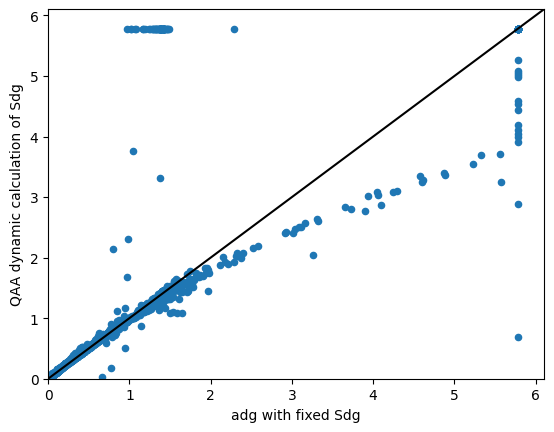

In [23]:
fig, ax = plt.subplots()

x = dat["adg_442"]
y = dat_mod["adg_442"]

ax.scatter(x, y, s=20)
ax.set_xlabel("adg with fixed Sdg")
ax.set_ylabel("QAA dynamic calculation of Sdg")
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color="black")
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)

plt.show()

[back to top](#Contents)